In [1]:
import requests
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
import os
from IPython.display import clear_output
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import gpytorch
from common import get_data, to_tensor
import constant as const
from call_GP import train_GP, ExactGPModel, evaluate_gp, call_model, cal_pos

url = "http://127.0.0.1:80"
testcase = 'bestest_air'
testid = \
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)

print("done")

Using: cuda
done


In [2]:
testid = \
requests.post('{0}/testcases/{1}/select'.format(url,testcase)).json()['testid']
name = requests.get('{0}/name/{1}'.format(url, testid)).json()['payload']
print(name)

version = requests.get('{0}/version'.format(url)).json()['payload']
print(version)
inputs = requests.get('{0}/inputs/{1}'.format(url, testid)).json()['payload']
print('TEST CASE INPUTS ---------------------------------------------')
print(inputs.keys())

print('TEST CASE MEASUREMENTS ---------------------------------------')
measurements = requests.get('{0}/measurements/{1}'.format(url, testid)).json()['payload']

{'name': 'bestest_air'}
{'version': '0.8.0'}
TEST CASE INPUTS ---------------------------------------------
dict_keys(['con_oveTSetCoo_activate', 'con_oveTSetCoo_u', 'con_oveTSetHea_activate', 'con_oveTSetHea_u', 'fcu_oveFan_activate', 'fcu_oveFan_u', 'fcu_oveTSup_activate', 'fcu_oveTSup_u'])
TEST CASE MEASUREMENTS ---------------------------------------


In [3]:
step = const.step

data = pd.read_csv(f'processed_uniform_low_step_5m_data.csv')
data_test = data

data.head()

T_zone = (data['zon_reaTRooAir_y'].values - 273.15) / 30.0
T_sup  = (data['fcu_oveTSup_u'].values - 273.15) / 40.0
fan  = data['fcu_oveFan_u'].values
T_out = (data['zon_weaSta_reaWeaTDryBul_y'].values - 273.15) / 10.0


pos_T_zone = T_zone[1:]
cur_T_zone = T_zone[:-1]
cur_T_sup = T_sup[:-1]
cur_fan = fan[:-1]
cur_T_out = T_out[:-1]


def data_split(Ns, Ne, x1, x2, x3, x4, x5):
    return (to_tensor(x1[Ns:Ne]).view(-1,1), to_tensor(x2[Ns:Ne]).view(-1,1),
            to_tensor(x3[Ns:Ne]).view(-1,1), to_tensor(x4[Ns:Ne]).view(-1,1), to_tensor(x5[Ns:Ne]).view(-1,1))


Ns_tr, Ne_tr = const.Ns_tr, const.Ne_tr  
Ns_t, Ne_t = const.Ns_t, const.Ne_t 
cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr, pos_T_zone_tr = data_split(Ns_tr, Ne_tr, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)
cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t, pos_T_zone_t = data_split(Ns_t, Ne_t, cur_T_zone, cur_T_sup, cur_fan, cur_T_out, pos_T_zone)

X_tr = torch.cat((cur_T_zone_tr, cur_T_sup_tr, cur_fan_tr, cur_T_out_tr), dim=1)
y_tr = pos_T_zone_tr.squeeze(-1)  
X_t = torch.cat((cur_T_zone_t, cur_T_sup_t, cur_fan_t, cur_T_out_t), dim=1)
y_t = pos_T_zone_t.squeeze(-1)

ramp = const.ramp

In [ ]:
class MPC:
    def __init__(self, X_tr, y_tr, model_path=f'model_AL_FI_GP_{step}m.pth'):
        self.likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
        self.model = ExactGPModel(X_tr, y_tr, self.likelihood).to(device)
        state_dict = torch.load(model_path, map_location=device)
        self.model.load_state_dict(state_dict)
        self.model.eval()
        self.X_tr = X_tr
        self.y_tr = y_tr

    def get_kernel_matrix(self, x):
        K = self.model.covar_module(x).evaluate()
        noise = self.model.likelihood.noise
        return K + noise * torch.eye(len(x), device=noise.device)



    def det_FI_ard_batch(self, x_candidates):
        """Batch compute log-det(FIM) for all candidate points simultaneously."""
        kernel = self.model.covar_module.base_kernel
        lengthscale = kernel.lengthscale.squeeze()
        out_scale   = self.model.covar_module.outputscale
        noise       = self.model.likelihood.noise

        X_base = self.X_tr
        m = x_candidates.shape[0]
        n = X_base.shape[0]
        d = X_base.shape[1]

        X_aug = torch.cat([
            X_base.unsqueeze(0).expand(m, -1, -1),
            x_candidates.unsqueeze(1)
        ], dim=1)

        diffs = X_aug.unsqueeze(2) - X_aug.unsqueeze(1)
        r2    = diffs ** 2

        exp_term   = torch.exp(-0.5 * (r2 / lengthscale**2).sum(-1))
        K_wo_noise = out_scale * exp_term

        I_n1 = torch.eye(n + 1, device=X_base.device, dtype=X_base.dtype)
        K = K_wo_noise + noise * I_n1
        L = torch.linalg.cholesky(K)

        dKs = [K_wo_noise]
        for i in range(d):
            dKs.append(K_wo_noise * r2[..., i] / lengthscale[i] ** 2)
        dKs.append(noise * I_n1.expand(m, -1, -1))

        p = len(dKs)

        Ms = [torch.cholesky_solve(dK, L) for dK in dKs]

        F = torch.zeros(m, p, p, device=X_base.device, dtype=X_base.dtype)
        for i in range(p):
            for j in range(i, p):
                val = 0.5 * (Ms[i] * Ms[j].transpose(-1, -2)).sum(dim=(-1, -2))
                F[:, i, j] = val
                if i != j:
                    F[:, j, i] = val

        _, log_det = torch.linalg.slogdet(F)
        return log_det

    def mpc_grid_search(self, x0, x_out, horizon=1, n_grid=20, u0_1=0.5, u0_2=0.5, plot=True):
        x0 = x0 / 30.0

        u_min_general = np.array([0.3, 0.0])
        u_max_general = np.array([1.0, 1.0])

        u_min = np.clip(np.array([u0_1 - ramp, u0_2 - ramp]), u_min_general, u_max_general)
        u_max = np.clip(np.array([u0_1 + ramp, u0_2 + ramp]), u_min_general, u_max_general)

        u1_vals = np.linspace(u_min[0], u_max[0], n_grid)
        u2_vals = np.linspace(u_min[1], u_max[1], n_grid)
        U1, U2 = np.meshgrid(u1_vals, u2_vals, indexing='ij')

        dtype = self.X_tr.dtype
        u1_flat = torch.tensor(U1.ravel(), dtype=dtype, device=device)
        u2_flat = torch.tensor(U2.ravel(), dtype=dtype, device=device)
        x0_col  = torch.full_like(u1_flat, x0)
        xo_col  = torch.full_like(u1_flat, x_out)
        candidates = torch.stack([x0_col, u1_flat, u2_flat, xo_col], dim=1)

        with torch.no_grad():
            log_dets = self.det_FI_ard_batch(candidates)

        cost_grid = log_dets.reshape(n_grid, n_grid).cpu().numpy()
        
        u0_1_t = torch.tensor(u0_1, dtype=dtype, device=device)
        u0_2_t = torch.tensor(u0_2, dtype=dtype, device=device)
        exclude = (u1_flat == u0_1_t) | (u2_flat == u0_2_t)
        log_dets_sel = log_dets.masked_fill(exclude, float('-inf'))
        best_flat = log_dets_sel.argmax().item()
        best_u    = np.array([u1_flat[best_flat].item(), u2_flat[best_flat].item()])



        if plot:
            plt.figure(figsize=(6,5))
            cp = plt.contourf(U1, U2, cost_grid, levels=30, cmap="viridis")
            plt.colorbar(cp, label="log det(FIM)")
            plt.scatter(best_u[0], best_u[1], c="red", marker="x", s=100)
            plt.xlabel("u1 (supply)")
            plt.ylabel("u2 (airflow)")
            plt.title("Grid Search Cost Landscape")
            plt.show()

        u = {
            'fcu_oveTSup_u': best_u[0] * 40 + 273.15,
            'fcu_oveTSup_activate': 1,
            'fcu_oveFan_u': best_u[1],
            'fcu_oveFan_activate': 1
        }
        return u

In [ ]:
y = requests.put('{0}/scenario/{1}'.format(url, testid), 
                 json={'time_period':'typical_heat_day',
                       'electricity_price':'dynamic'}).json()['payload']['time_period']
requests.put('{0}/step/{1}'.format(url, testid), json={'step':step*60})
start_time_days = y['time']/3600/24
train_GP(X_tr=X_tr, y_tr=y_tr, save_path=f'model_AL_FI_GP_{step}m.pth', ori=0)

In [ ]:
last_change_day = start_time_days
counter = 0
u0_1 = 0.5
u0_2 = 0.5
u = {
        'fcu_oveTSup_u': u0_1 * 40 + 273.15,
        'fcu_oveTSup_activate': 1,
        'fcu_oveFan_u': u0_2,
        'fcu_oveFan_activate': 1
        }

x_ref = 25
simulation_time_days = y['time']/3600/24
print('Simulation time [elapsed days] = {:.2f}'.format((simulation_time_days - start_time_days)))
y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  

ls_rmse = [evaluate_gp(X_tr, y_tr, X_t, y_t, save_path=f'model_AL_FI_GP_{step}m.pth')]
X_tr_new = X_tr
y_tr_new = y_tr
num_count = const.num_count

Simulation time [elapsed days] = 0.00


In [ ]:
while y:
    x0 = y['zon_reaTRooAir_y']-273.15
    x_out = (y['zon_weaSta_reaWeaTDryBul_y']-273.15)/10.0
    mpc_controller = MPC(X_tr_new, y_tr_new, model_path=f'model_AL_FI_GP_{step}m.pth')
    u = mpc_controller.mpc_grid_search(x0=x0, x_out=x_out, horizon=1, u0_1=u0_1, u0_2=u0_2, n_grid=10, plot =False)

    print('-------------------------------------------------------------------')
    print('Step counter =', counter)
    print("Controller output:", u)

    y = requests.post('{0}/advance/{1}'.format(url, testid), json=u).json()['payload']  
    counter += 1


    cur = to_tensor(x0).view(-1,1)/30.0
    T_sup_add=  to_tensor((u['fcu_oveTSup_u']-273.15)/40.0).view(-1,1)
    fan_add = to_tensor(u['fcu_oveFan_u']).view(-1,1)
    pos_add = to_tensor(y['zon_reaTRooAir_y']-273.15).view(-1,1)/30.0

    T_out_add = to_tensor((y['zon_weaSta_reaWeaTDryBul_y']-273.15)/10.0).view(-1,1)

    X_tr_n = torch.cat((cur, T_sup_add, fan_add, T_out_add), dim=1)

    y_tr_n = pos_add.squeeze(-1)   

    X_tr_new = torch.cat((X_tr_new, X_tr_n), dim=0)
    y_tr_new = torch.cat((y_tr_new, y_tr_n), dim=0)
    
    if const.count_data == const.number_of_data:
        train_GP(X_tr=X_tr_new, y_tr=y_tr_new, save_path=f'model_AL_FI_GP_{step}m.pth', ori=1)
        print("=============================== Retrained the GP model ==============================")
        const.count_data = 0
    const.count_data += 1
    
    simulation_time_days = y['time']/3600/24
    print('Simulation time [elapsed days] = {:.2f}'.format((simulation_time_days - start_time_days)))

    u0_1 = (u['fcu_oveTSup_u']-273.15)/40.0
    u0_2 = u['fcu_oveFan_u']

    rmse = evaluate_gp(X_tr_new, y_tr_new, X_t, y_t, save_path=f'model_AL_FI_GP_{step}m.pth')

    ls_rmse.append(rmse)
    if counter > num_count:
        break

-------------------------------------------------------------------
Step counter = 0
Controller output: {'fcu_oveTSup_u': np.float64(285.15000047683714), 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': np.float64(0.6111111044883728), 'fcu_oveFan_activate': 1}
Simulation time [elapsed days] = 0.01
-------------------------------------------------------------------
Step counter = 1
Controller output: {'fcu_oveTSup_u': np.float64(293.15), 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': np.float64(0.41111111640930176), 'fcu_oveFan_activate': 1}
Simulation time [elapsed days] = 0.01
-------------------------------------------------------------------
Step counter = 2
Controller output: {'fcu_oveTSup_u': np.float64(301.1499995231628), 'fcu_oveTSup_activate': 1, 'fcu_oveFan_u': np.float64(0.6111111044883728), 'fcu_oveFan_activate': 1}
Simulation time [elapsed days] = 0.01
-------------------------------------------------------------------
Step counter = 3
Controller output: {'fcu_oveTSup_u': np.float64(

<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
<>:33: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
C:\Users\namng\AppData\Local\Temp\ipykernel_24696\137404845.py:33: SyntaxWarning: invalid escape sequence '\c'
  axs[0].set_ylabel('Operative\nTemp ($^\circ$C)')
C:\Users\namng\AppData\Local\Temp\ipykernel_24696\137404845.py:39: SyntaxWarning: invalid escape sequence '\c'
  axs[1].set_ylabel('Ambient\nTemp ($^\circ$C)')


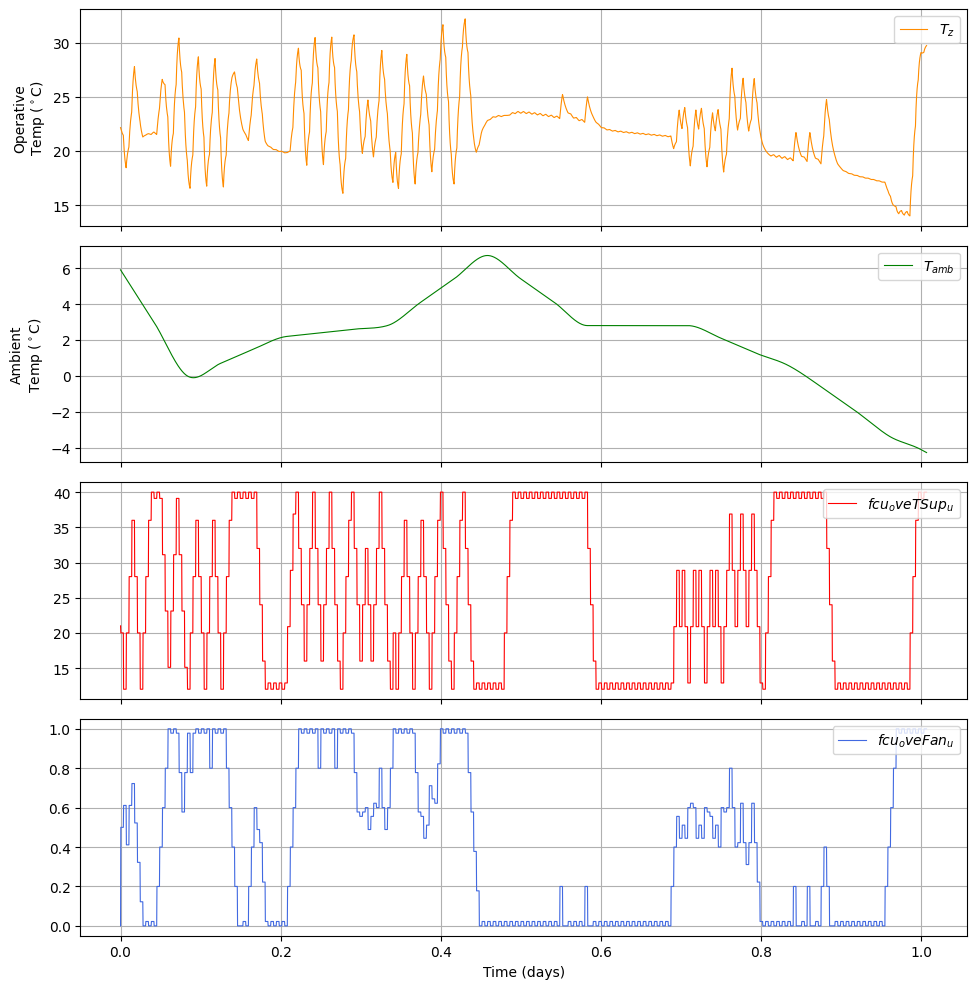

,zon_reaTRooAir_y,fcu_oveTSup_u,fcu_oveFan_u,zon_weaSta_reaWeaTDryBul_y,time
time,,,,,
3801600,295.310128,294.15,0.0,279.050000,0.000000
3801630,295.222125,293.15,0.5,279.025812,0.000347
3801660,295.117210,293.15,0.5,279.001625,0.000694
3801690,295.023884,293.15,0.5,278.977439,0.001042
3801720,294.940950,293.15,0.5,278.953254,0.001389
...,...,...,...,...,...
3888480,302.755956,313.15,1.0,268.916667,1.005556
3888510,302.800883,313.15,1.0,268.908333,1.005903
3888540,302.840230,313.15,1.0,268.900000,1.006250


In [8]:
def get_and_plot_results(testid, start_time, final_time):
    points = ['zon_reaTRooAir_y', 'fcu_oveTSup_u', 'fcu_oveFan_u', 'zon_weaSta_reaWeaTDryBul_y']
    args = {
        'point_names': points,
        'start_time': start_time, 
        'final_time': final_time
    }
    
    response = requests.put('{0}/results/{1}'.format(url, testid), json=args).json()
    
    if 'payload' not in response:
        print("Error: Could not retrieve data. Check if testid is still active.")
        return None
        
    df_res = pd.DataFrame(data=response['payload'])
    
    df_res = df_res.set_index('time')
    x_time = df_res.index / 3600. / 24.
    x_time = x_time - (start_time / 3600. / 24.)
    df_res['time'] = x_time
    

    plt.close('all')
    fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 10))
    
    axs[0].plot(x_time, df_res['zon_reaTRooAir_y'] - 273.15, color='darkorange', linewidth=0.8, label='$T_z$')
    axs[0].set_ylabel('Operative\nTemp ($^\circ$C)')
    axs[0].legend(loc='upper right')
    axs[0].grid(True)

    axs[1].plot(x_time, df_res['zon_weaSta_reaWeaTDryBul_y'] - 273.15, color='green', linewidth=0.8, label='$T_{amb}$')
    axs[1].set_ylabel('Ambient\nTemp ($^\circ$C)')
    axs[1].legend(loc='upper right')
    axs[1].grid(True)

    axs[2].plot(x_time, df_res['fcu_oveTSup_u'] - 273.15, color='red', linewidth=0.8, label='$fcu_oveTSup_u$')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)

    axs[3].plot(x_time, df_res['fcu_oveFan_u'], color='royalblue', linewidth=0.8, label='$fcu_oveFan_u$')
    axs[3].set_xlabel('Time (days)')
    axs[3].legend(loc='upper right')
    axs[3].grid(True)

    plt.tight_layout()
    plt.show()
    
    return df_res

start_in_seconds = start_time_days * 24 * 3600
final_in_seconds = start_in_seconds + (14 * 24 * 3600)

get_and_plot_results(testid=testid, start_time=start_in_seconds, final_time=final_in_seconds)

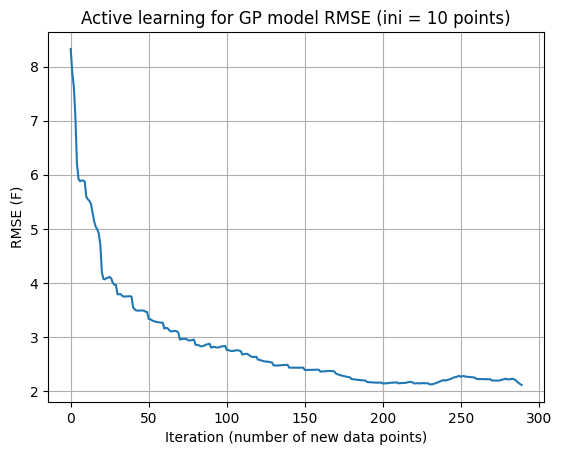

In [9]:
ls_rmse = [r.cpu()*30 for r in ls_rmse]    
plt.plot(ls_rmse)
plt.xlabel('Iteration (number of new data points)')
plt.grid()
plt.ylabel('RMSE (F)')
plt.title('Active learning for GP model RMSE (ini = 10 points)')
plt.show()

In [ ]:
import os
save_dir = 'results'
os.makedirs(save_dir, exist_ok=True)
df = pd.DataFrame(np.array(ls_rmse), columns=["RMSE_FI_GP"])
file_name = f"RMSE_FI_GP_ini{Ne_tr}_{const.ramp}.csv"
save_dir = os.path.join(save_dir, file_name)
df.to_csv(save_dir, index=False)

: 